In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

torch.manual_seed(0)
np.random.seed(0)

import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from neural_decoder.neural_decoder_trainer import getDatasetLoaders

In [2]:
import pickle

with open('../data/ptDecoder_ctc', "rb") as handle:
    loadedData = pickle.load(handle)

In [3]:
from neural_decoder.dataset import SpeechDataset
train_ds = SpeechDataset(loadedData["train"], transform=None)

In [4]:
num_trials = 8800
num_electrodes = 128
num_feats = 2

# Creates single concatenated list per electrode per feature
buffers = [[[] for _ in range(num_electrodes)] for _ in range(num_feats)]

for i in range(num_trials):
    X = train_ds[i][0]
    X = X.squeeze().numpy()
    L = X.shape[0]

    trial_fc = X.reshape(L, num_feats, num_electrodes)

    for f in range(num_feats):
        data_f = trial_fc[:, f, :]
        for ch in range(num_electrodes):
            buffers[f][ch].append(data_f[:, ch])

# final vectors: feature × channel × samples
channel_vectors = [
    np.array([np.concatenate(buffers[f][ch]) for ch in range(num_electrodes)])
    for f in range(num_feats)
]

threshold_crossings = channel_vectors[0]
spike_band_power = channel_vectors[1]

In [5]:
tc_centered = threshold_crossings - threshold_crossings.mean(axis=1).reshape(-1, 1)
sbp_centered = spike_band_power - spike_band_power.mean(axis=1).reshape(-1, 1)

In [6]:
cov_tc = tc_centered @ tc_centered.T / tc_centered.shape[1]
cov_sbp = sbp_centered @ sbp_centered.T / sbp_centered.shape[1]

In [7]:
evals_tc, pcs_tc = np.linalg.eig(cov_tc)
evals_sbp, pcs_sbp = np.linalg.eig(cov_sbp)

In [8]:
pc_var_tc = np.cumsum(evals_tc) / evals_tc.sum()
np.where(pc_var_tc > 0.9)[0].min()

114

In [9]:
pc_var_sbp = np.cumsum(evals_sbp) / evals_sbp.sum()
np.where(pc_var_sbp > 0.9)[0].min()

114

We need 114 out of 128 principal components from both the threshold crossings and spike band powers in order to keep 90% of the overall variance in the data.

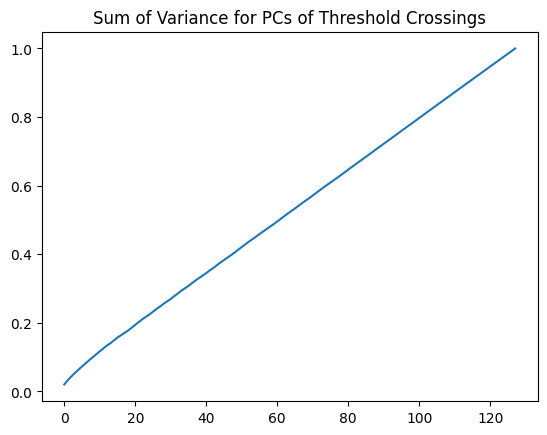

In [10]:
plt.plot(np.cumsum(evals_tc) / evals_tc.sum())
plt.title('Sum of Variance for PCs of Threshold Crossings')
plt.show()

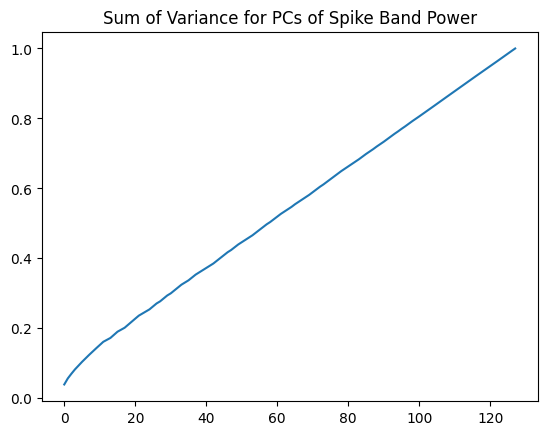

In [11]:
plt.plot(np.cumsum(evals_sbp) / evals_sbp.sum())
plt.title('Sum of Variance for PCs of Spike Band Power')
plt.show()

In [42]:
np.save("../data/threshold_crossing_principal_components.npy", pcs_tc)
np.save("../data/threshold_crossings_mean.npy", threshold_crossings.mean(axis=1).reshape(-1, 1))

np.save("../data/spike_band_power_principal_components.npy", pcs_sbp)
np.save("../data/spike_band_power_mean.npy", spike_band_power.mean(axis=1).reshape(-1, 1))